# Optimización day-ahead de costos en microrred aislada
**EMS, MILP, UC+ED, scheduling**

V1: Versión en PYOMO basado en [https://gurobipy-pandas.readthedocs.io/en/stable/examples/unit-commitment.html](https://gurobipy-pandas.readthedocs.io/en/stable/examples/unit-commitment.html) y en el Ejemplo 12.15 del libro [Model Building in Mathematical Programming](https://share.google/ovWcmGq54LiyOcWm8) de H. Paul Williams (5ª edición, págs. 270-271 y 325-326).

Formulación MILP con:
- Satisfacción exacta de la demanda neta (demanda menos generación FV) por período
- Restricción de reserva operativa (15% sobre la demanda neta)
- Costos fijos por generador activo, costos marginales y costos de arranque
- Objetivo: minimizar costo total de operación

V2: El problema de Williams de despacho nacional (≈ 45 GW) redimensionado a escala de microrred (≈ 2.1 MW pico). Se reeplazaron los generadores térmicos por generadores diesel.

V3: Se pasa de una representación agregada de la demanda en 5 bloques horarios a una discretización horaria completa (24 períodos), lo cual permite capturar con mayor fidelidad las rampas de demanda, especialmente en los períodos de transición (mañana y tarde).

V4: Se agregan restricciones de rampa (ramp-up y ramp-down) para limitar la tasa de cambio de producción entre períodos consecutivos. Las restricciones se formulan de manera trivialmente satisfecha (ramp_limit = Pmax) dado que los generadores diesel tienen una dinámica de carga mucho más rápida que el paso de tiempo de 1 hora.

V5: Se incorpora un generador fotovoltaico (GFV). Los datos de irradiancia y temperatura corresponden al parque solar de la UTN FR Santa Fe, día 01/01/2019 (promedios horarios).

## Problema: Gestión Energética de Microrred con generadores despachables y generación renovable

Una flota de 27 grupos generadores diesel está disponible para satisfacer la demanda eléctrica de una microrred aislada a lo largo de un día:

|       demand_hourly             |                                    |
| :-------------------------------| :--------------------------------- |
|   820, 790, 810, 800, 830, 870, |  00–05: valle nocturno             |
|  1050,1380,1575,1420,1350,1380, |  06–11: rampa matutina y mañana    |
|  1520,1480,1400,1620,1850,2050, |  12–17: tarde y rampa vespertina   |
|  2100,1980,1750,1550,1350,1100, |  18–23: pico y descenso nocturno   |

Hay tres tipos de generadores diesel disponibles, 12 pequeños (40 KW), 10 medianos (100 KW) y 5 grandes (250 KW). Cada generador opera entre un nivel mínimo (50% de capacidad nominal) y un nivel máximo. Existen costos de O&M (operación y mantenimiento) fijos, costos de combustible (modelados con curva cuadrática linealizada), costos de arranque y de apagado. Cada generador debe permanecer encendido/apagado un tiempo mínimo tras cada transición de estado. La capacidad total instalada es 2.730 kW (12×40 + 10×100 + 5×250). Considerando la reserva del 15%, la demanda máxima factible es ≈ 2.374 kW, por lo que el pico de 2.100 kW tiene margen de seguridad.

Además, se dispone de un generador fotovoltaico de 400 kWp (1000 módulos × 400 Wp). Al ser una fuente no gestionable (no controlable), su producción horaria $P^{\mathrm{PV}}_t$ se calcula en pre-proceso mediante el modelo de Loyarte y se descuenta de la demanda bruta. Los generadores diesel deben cubrir únicamente la demanda neta:

$$D^{\mathrm{net}}_t = D_t - P^{\mathrm{PV}}_t \geq 0 \qquad \forall t \in T$$

Los datos de demanda durante las 24 horas y las características de los generadores se muestran en la sección Carga de datos.

In [1]:
import pyomo.environ as pe
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

## Modelo de Generador Fotovoltaico
**Enfoque Loyarte (2019)**

La potencia eléctrica entregada por un GFV con $N$ módulos idénticos operando en MPP (Maximum Power Point) es:

$$P_{\mathrm{PV}}[kW] = N \cdot \frac{G}{G_{\mathrm{std}}} \cdot P_{\mathrm{pico}} \cdot \bigl[1 + k_p \cdot (T_c - T_r)\bigr] \cdot \eta \cdot 10^{-3} \tag{1}$$

donde la temperatura de celda se estima a partir de la temperatura ambiente y la irradiancia incidente (modelo simplificado sin viento):

$$T_c = T + 0{,}031\,[°C \cdot m^2/W] \cdot G \tag{2}$$

**Parámetros del GFV modelado:**

| Parámetro | Símbolo | Valor | Unidad | Descripción |
|:---|:---:|---:|:---:|:---|
| Módulos instalados | $N$ | 1 000 | — | Cantidad de paneles |
| Potencia pico por módulo | $P_{\mathrm{pico}}$ | 400 | W | Módulo policristalino típico |
| Potencia nominal total | — | 400 | kWp | $N \times P_{\mathrm{pico}} \times 10^{-3}$ |
| Irradiancia estándar | $G_{\mathrm{std}}$ | 1 000 | W/m² | Condición STC fabricante |
| Temperatura de referencia | $T_r$ | 25 | °C | Condición STC fabricante |
| Coeficiente temp.-potencia | $k_p$ | −0,0045 | °C⁻¹ | Pérdida ≈ 0,45 %/°C (Si policrist.) |
| Rendimiento global | $\eta$ | 0,92 | p.u. | Incluye inversor y pérdidas BOS |

> **Nota:** Como se indica en Loyarte, las mediciones de irradiancia de la estación meteorológica se toman sobre superficie horizontal. En este ejercicio se asume, por simplicidad, que los valores corresponden directamente a $G$ (irradiancia normal a los módulos).

In [2]:
# ── Parámetros del GFV (Loyarte) ─────────────────────────────────────────────
PV_N      = 1000    # módulos
PV_Ppico  = 400     # W por módulo
PV_kp     = -0.0045 # °C⁻¹ coeficiente temperatura-potencia
PV_Tr     = 25.0    # °C temperatura de referencia
PV_Gstd   = 1000.0  # W/m² irradiancia estándar
PV_eta    = 0.92    # rendimiento global (inversor + BOS)

def loyarte_pv(G, T_amb, N=PV_N, Ppico=PV_Ppico, kp=PV_kp,
               Tr=PV_Tr, Gstd=PV_Gstd, eta=PV_eta):
    """Modelo Loyarte (ec. 1-2). Retorna P_PV en kW."""
    if G <= 0:
        return 0.0
    Tc = T_amb + 0.031 * G                           # ec. (2): temperatura de celda
    P  = N * (G / Gstd) * Ppico * (1 + kp*(Tc-Tr)) * eta * 1e-3  # ec. (1): potencia [kW]
    return max(P, 0.0)                               # no puede ser negativa

# ── Carga de datos solares y cálculo del perfil PV ───────────────────────────
solar_data = pd.read_csv("data/GFV_UTN_santafe.csv", index_col="hora")

pv_profile = {}
for h in range(24):
    G   = solar_data.loc[h, 'irradiancia']
    T   = solar_data.loc[h, 'temperatura']
    pv_profile[h] = round(loyarte_pv(G, T), 2)

print(f"GFV: {PV_N} módulos × {PV_Ppico} Wp = {PV_N*PV_Ppico/1000:.0f} kWp nominales")
print(f"     kp={PV_kp} °C⁻¹ | η={PV_eta} | Tr={PV_Tr}°C | Gstd={PV_Gstd} W/m²")
print()
print(f"{'Hora':>5} {'G (W/m²)':>10} {'T_amb (°C)':>11} {'T_c (°C)':>10} {'P_PV (kW)':>11}")
print("-" * 50)
for h in range(24):
    G  = solar_data.loc[h, 'irradiancia']
    T  = solar_data.loc[h, 'temperatura']
    Tc = T + 0.031*G if G > 0 else T
    print(f"{h:>5} {G:>10.2f} {T:>11.2f} {Tc:>10.2f} {pv_profile[h]:>11.1f}")
print("-" * 50)
print(f"{'Pico':>5} {'':>10} {'':>11} {'':>10} {max(pv_profile.values()):>11.1f}  kW")
print(f"{'Total':>5} {'':>10} {'':>11} {'':>10} {sum(pv_profile.values()):>11.1f}  kWh/día")

GFV: 1000 módulos × 400 Wp = 400 kWp nominales
     kp=-0.0045 °C⁻¹ | η=0.92 | Tr=25.0°C | Gstd=1000.0 W/m²

 Hora   G (W/m²)  T_amb (°C)   T_c (°C)   P_PV (kW)
--------------------------------------------------
    0       0.00       27.90      27.90         0.0
    1       0.00       27.55      27.55         0.0
    2       0.00       27.17      27.17         0.0
    3       0.00       26.81      26.81         0.0
    4       0.00       26.48      26.48         0.0
    5       0.00       26.13      26.13         0.0
    6      16.00       26.36      26.86         5.8
    7      89.16       27.53      30.29        32.0
    8     335.67       29.08      39.49       115.5
    9     540.83       32.10      48.87       177.7
   10     679.33       32.40      53.46       218.0
   11     990.67       33.98      64.69       299.4
   12     773.17       35.03      59.00       241.0
   13     739.00       34.73      57.64       232.0
   14     196.50       30.81      36.90        68.4
   15   

## Carga de Datos

In [3]:
generator_data = pd.read_csv("data/generators_diesel_v5.csv", index_col="generator_class")
generator_data

,num_available,min_output,max_output,cost_per_hour,startup_cost,shutdown_cost,min_up_time,min_down_time,ramp_limit,state0
generator_class,,,,,,,,,,
diesel_small,12,20.0,40.0,2.5,5.0,2.5,1,1,40.0,0
diesel_med,10,50.0,100.0,5.8,12.0,6.0,1,1,100.0,0
diesel_large,5,125.0,250.0,14.5,25.0,12.5,1,1,250.0,0


In [4]:
time_period_data = pd.read_csv("data/time_periods_v5.csv", parse_dates=["time_period"],
    index_col="time_period")
time_period_data

,expected_demand
time_period,
2024-01-01 00:00:00,820
2024-01-01 01:00:00,790
2024-01-01 02:00:00,810
2024-01-01 03:00:00,800
2024-01-01 04:00:00,830
2024-01-01 05:00:00,870
2024-01-01 06:00:00,1050
2024-01-01 07:00:00,1380
2024-01-01 08:00:00,1575


In [5]:
solar_data_df = pd.read_csv("data/GFV_UTN_santafe.csv", index_col="hora")
solar_data_df

,irradiancia,temperatura
hora,,
0,0.00,27.90
1,0.00,27.55
2,0.00,27.17
3,0.00,26.81
4,0.00,26.48
5,0.00,26.13
6,16.00,26.36
7,89.16,27.53
8,335.67,29.08


## Conjuntos

In [6]:
GENERATORS   = list(generator_data.index)        # ['diesel_small', 'diesel_med', 'diesel_large']
TIME_PERIODS = list(time_period_data.index)       # lista de timestamps
T            = list(range(len(TIME_PERIODS)))     # índices enteros 0..23 para Pyomo

print(f"Clases de generadores : {GENERATORS}")
print(f"Número de períodos    : {len(T)}")

Clases de generadores : ['diesel_small', 'diesel_med', 'diesel_large']
Número de períodos    : 24


## Parámetros

Los parámetros del modelo se construyen como diccionarios Python a partir de los DataFrames cargados.

- $n_g$: unidades disponibles de la clase $g$
- $P^{\min}_g$, $P^{\max}_g$: límites de producción por unidad [kW]
- $c_g$: costo fijo de O&M por hora por unidad activa [$/h]
- $s^u_g$: costo de arranque [$]
- $s^d_g$: costo de apagado [$]
- $\tau^{\mathrm{up}}_g$, $\tau^{\mathrm{dn}}_g$: tiempos mínimos de encendido/apagado [períodos]
- $a^0_g$: estado inicial (unidades activas antes del primer período)
- $P^{\mathrm{PV}}_t$: potencia fotovoltaica en el período $t$ [kW] — calculada con modelo Loyarte
- $D_t$: demanda bruta esperada en el período $t$ [kW]
- $D^{\mathrm{net}}_t = D_t - P^{\mathrm{PV}}_t$: demanda neta a cubrir por diesel en $t$ [kW]
- $\bar{D}^{\mathrm{net}}_t = 1{,}15 \cdot D^{\mathrm{net}}_t$: capacidad activa mínima requerida en $t$ [kW]
- $S_j^g$, $s_j^g$: pendiente e intercepto del segmento $j$ de la curva de combustible de la clase $g$

In [7]:
# ── Parámetros por clase de generador ───────────────────────────────────────
num_available = generator_data['num_available'].to_dict()
min_output    = generator_data['min_output'].to_dict()
max_output    = generator_data['max_output'].to_dict()
cost_per_hour = generator_data['cost_per_hour'].to_dict()
startup_cost  = generator_data['startup_cost'].to_dict()
shutdown_cost = generator_data['shutdown_cost'].to_dict()
min_up_time   = generator_data['min_up_time'].to_dict()
min_down_time = generator_data['min_down_time'].to_dict()
ramp_limit    = generator_data['ramp_limit'].to_dict()
state0        = generator_data['state0'].to_dict()

# ── Parámetros por período (indexados por entero) ────────────────────────────
expected_demand         = {i: time_period_data['expected_demand'].iloc[i] for i in T}

# Potencia PV horaria ya calculada en pre-proceso (modelo Loyarte)
pv_output               = {i: pv_profile[i] for i in T}

# Demanda neta = demanda bruta − generación PV
net_demand              = {i: expected_demand[i] - pv_output[i] for i in T}

# Capacidad activa mínima basada en demanda neta (reserva 15%)
minimum_active_capacity = {i: round(net_demand[i] * 1.15, 2) for i in T}

## Linealización de la Curva de Costo de Combustible
### Enfoque Parisio (2014)

Dado que los MILP son computacionalmente más eficientes que los MIQP, la función de costo de combustible de un generador diesel:

$$f(P) = a P^2 + b P \quad [\text{\$/h}]$$

se aproxima por el máximo de funciones afines sin introducir variables binarias adicionales:

$$f(P) \approx \sigma = \max_{j=1,\dots,n}\{S_j P + s_j\}$$

donde los coeficientes de cada segmento $j$ se obtienen evaluando la tangente de $f$ en el punto de soporte $P_j$:

$$S_j = f'(P_j) = 2aP_j + b \qquad s_j = f(P_j) - S_j P_j = -aP_j^2$$

Extensión a clases de generadores (formulación agregada): si hay $n_{g,t}$ unidades activas de la clase $g$ produciendo $P^{\mathrm{D}}_{g,t}$ kW en total, el costo de combustible agregado es:

$$n_{g,t} \cdot f\!\left(\frac{P^{\mathrm{D}}_{g,t}}{n_{g,t}}\right) = a\frac{{P^{\mathrm{D}}_{g,t}}^2}{n_{g,t}} + b\, P^{\mathrm{D}}_{g,t}$$

Con la aproximación lineal tangente en cada punto de soporte, esto se convierte en el conjunto de restricciones lineales:

$$\sigma_{g,t} \geq S_j^{g} \cdot P^{\mathrm{D}}_{g,t} + s_j^{g} \cdot n_{g,t} \qquad \forall j = 1, \dots, n_{\mathrm{seg}}$$

Esta formulación es lineal porque $S_j^{g}$ y $s_j^{g}$ son constantes, $P^{\mathrm{D}}_{g,t}$ es continua y $n_{g,t}$ es entera.

Se definen los coeficientes cuadráticos de la función de costo de combustible por unidad:

$$f_g(P) = a_g P^2 + b_g P \quad [\text{\$/h}]$$

y se calculan los segmentos lineales evaluando las tangentes en $n_{\mathrm{seg}} = 3$ puntos de soporte equidistantes entre $P^{\min}_g$ y $P^{\max}_g$.

Los coeficientes (Tabla 2.1 de Nemati) $a$ en $ml/kW^{2}h$ y $b$ en $l/kWh$ se multiplicaron por un precio de combustible estimado de $1.2 $/l$.


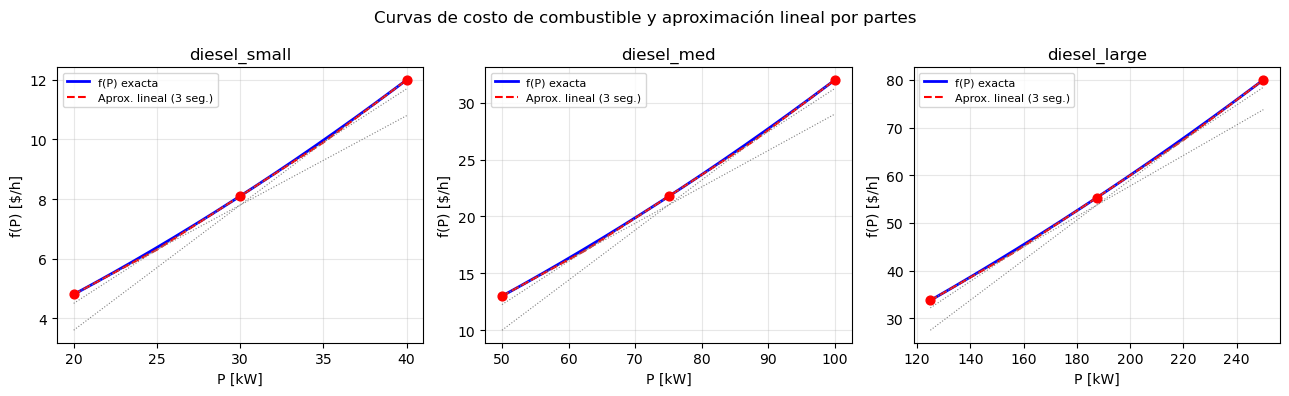


Segmentos lineales de la curva de combustible:
Clase           Seg   P_soporte (kW)   Pendiente S_j   Intercepto s_j
--------------------------------------------------------------------
diesel_small      0             20.0         0.30000          -1.2000
diesel_small      1             30.0         0.36000          -2.7000
diesel_small      2             40.0         0.42000          -4.8000

diesel_med        0             50.0         0.32000          -3.0000
diesel_med        1             75.0         0.38000          -6.7500
diesel_med        2            100.0         0.44000         -12.0000

diesel_large      0            125.0         0.32000          -6.2500
diesel_large      1            187.5         0.37000         -14.0625
diesel_large      2            250.0         0.42000         -25.0000



In [8]:
quad_params = {
    'diesel_small': {'a': 0.003,   'b': 0.18},
    'diesel_med':   {'a': 0.0012,  'b': 0.20},
    'diesel_large': {'a': 0.0004,  'b': 0.22},
}

N_SEG = 3

lin_segments = {}
for g in GENERATORS:
    a  = quad_params[g]['a']
    b  = quad_params[g]['b']
    support_points = np.linspace(min_output[g], max_output[g], N_SEG)
    slopes     = [2 * a * pj + b for pj in support_points]
    intercepts = [-a * pj**2      for pj in support_points]
    lin_segments[g] = {'slopes': slopes, 'intercepts': intercepts, 'support': support_points}

SEGMENTS = list(range(N_SEG))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Curvas de costo de combustible y aproximación lineal por partes", fontsize=12)

for ax, g in zip(axes, GENERATORS):
    a = quad_params[g]['a']; b = quad_params[g]['b']
    P = np.linspace(min_output[g], max_output[g], 200)
    f_exact  = a * P**2 + b * P
    f_approx = np.max(np.array([lin_segments[g]['slopes'][j]*P + lin_segments[g]['intercepts'][j]
                                 for j in SEGMENTS]), axis=0)
    ax.plot(P, f_exact,  'b-',  lw=2,   label='f(P) exacta')
    ax.plot(P, f_approx, 'r--', lw=1.5, label='Aprox. lineal (3 seg.)')
    for j in SEGMENTS:
        ax.plot(P, lin_segments[g]['slopes'][j]*P + lin_segments[g]['intercepts'][j],
                'gray', lw=0.8, ls=':')
    ax.scatter(lin_segments[g]['support'],
               [a*pj**2+b*pj for pj in lin_segments[g]['support']],
               color='red', zorder=5, s=40)
    ax.set_xlabel("P [kW]"); ax.set_ylabel("f(P) [$/h]")
    ax.set_title(g); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print("\nSegmentos lineales de la curva de combustible:")
print(f"{'Clase':<14} {'Seg':>4} {'P_soporte (kW)':>16} {'Pendiente S_j':>15} {'Intercepto s_j':>16}")
print("-" * 68)
for g in GENERATORS:
    for j in SEGMENTS:
        print(f"{g:<14} {j:>4} {lin_segments[g]['support'][j]:>16.1f} {lin_segments[g]['slopes'][j]:>15.5f} {lin_segments[g]['intercepts'][j]:>16.4f}")
    print()

## Perfil de Generación Fotovoltaica

Visualización del perfil horario calculado con el modelo Loyarte, junto con los datos de entrada (irradiancia y temperatura de celda).

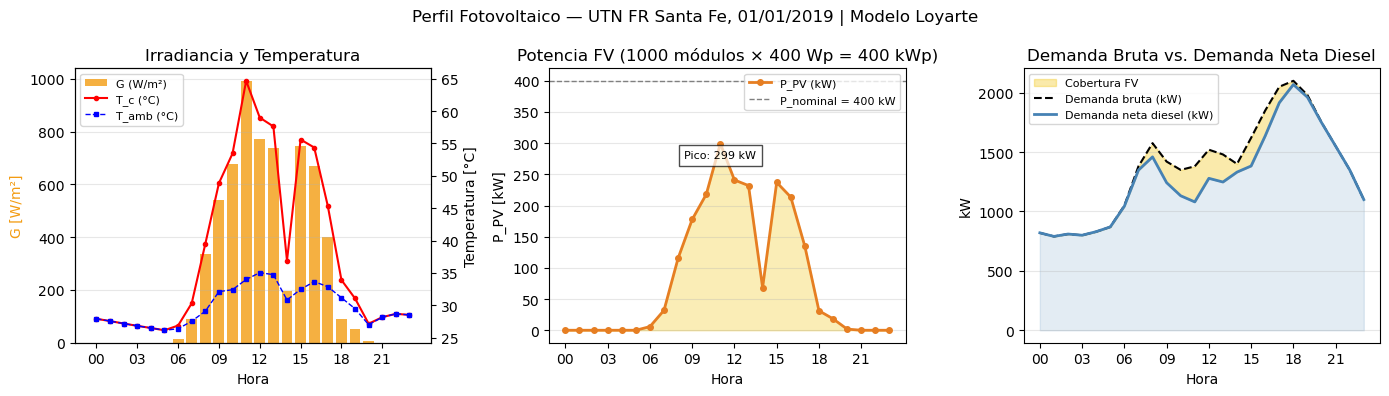

Energía FV total     : 2026.5 kWh/día
Energía demanda total: 32825 kWh/día
Fracción FV          : 6.2%
Reducción pico diesel: 31.3 kW → demanda neta máx = 2069 kW


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Perfil Fotovoltaico — UTN FR Santa Fe, 01/01/2019 | Modelo Loyarte", fontsize=12)

hours_x = list(range(24))
irrad_vals = [solar_data_df.loc[h,'irradiancia'] for h in hours_x]
temp_vals  = [solar_data_df.loc[h,'temperatura'] for h in hours_x]
tc_vals    = [solar_data_df.loc[h,'temperatura'] + 0.031*solar_data_df.loc[h,'irradiancia'] for h in hours_x]
pv_vals    = [pv_profile[h] for h in hours_x]
demand_bruta = [expected_demand[h] for h in hours_x]
demand_neta  = [net_demand[h] for h in hours_x]

# Irradiancia y temperatura de celda
ax1 = axes[0]
ax1.bar(hours_x, irrad_vals, color='#f39c12', alpha=0.8, label='G (W/m²)', width=0.8)
ax1.set_xlabel('Hora'); ax1.set_ylabel('G [W/m²]', color='#f39c12')
ax1b = ax1.twinx()
ax1b.plot(hours_x, tc_vals, 'r-o', ms=3, lw=1.5, label='T_c (°C)')
ax1b.plot(hours_x, temp_vals, 'b--s', ms=3, lw=1, label='T_amb (°C)')
ax1b.set_ylabel('Temperatura [°C]')
lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1+lines2, lbl1+lbl2, fontsize=8, loc='upper left')
ax1.set_title('Irradiancia y Temperatura')
ax1.set_xticks(range(0,24,3)); ax1.set_xticklabels([f'{h:02d}' for h in range(0,24,3)])
ax1.grid(alpha=0.3, axis='y')

# Potencia PV
ax2 = axes[1]
ax2.fill_between(hours_x, pv_vals, alpha=0.3, color='#f1c40f')
ax2.plot(hours_x, pv_vals, 'o-', color='#e67e22', lw=2, ms=4, label='P_PV (kW)')
ax2.axhline(PV_N*PV_Ppico/1000, color='gray', lw=1, ls='--',
            label=f'P_nominal = {PV_N*PV_Ppico/1000:.0f} kW')
ax2.set_xlabel('Hora'); ax2.set_ylabel('P_PV [kW]')
ax2.set_title(f'Potencia FV ({PV_N} módulos × {PV_Ppico} Wp = {PV_N*PV_Ppico/1000:.0f} kWp)')
ax2.set_xticks(range(0,24,3)); ax2.set_xticklabels([f'{h:02d}' for h in range(0,24,3)])
ax2.legend(fontsize=8); ax2.grid(alpha=0.3, axis='y')
ax2.text(11, max(pv_vals)*0.92, f'Pico: {max(pv_vals):.0f} kW', ha='center', fontsize=8,
         bbox=dict(facecolor='white', alpha=0.7))

# Demanda bruta vs neta
ax3 = axes[2]
ax3.fill_between(hours_x, demand_bruta, demand_neta, alpha=0.35, color='#f1c40f', label='Cobertura FV')
ax3.fill_between(hours_x, demand_neta, alpha=0.15, color='steelblue')
ax3.plot(hours_x, demand_bruta, 'k--', lw=1.5, label='Demanda bruta (kW)')
ax3.plot(hours_x, demand_neta,  'steelblue', lw=2, label='Demanda neta diesel (kW)')
ax3.set_xlabel('Hora'); ax3.set_ylabel('kW')
ax3.set_title('Demanda Bruta vs. Demanda Neta Diesel')
ax3.set_xticks(range(0,24,3)); ax3.set_xticklabels([f'{h:02d}' for h in range(0,24,3)])
ax3.legend(fontsize=8); ax3.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

total_pv_energy  = sum(pv_vals)
total_bruta_energy = sum(demand_bruta)
print(f"Energía FV total     : {total_pv_energy:.1f} kWh/día")
print(f"Energía demanda total: {total_bruta_energy:.0f} kWh/día")
print(f"Fracción FV          : {100*total_pv_energy/total_bruta_energy:.1f}%")
print(f"Reducción pico diesel: {max(demand_bruta)-max(demand_neta):.1f} kW → demanda neta máx = {max(demand_neta):.0f} kW")

## Construcción del Modelo Pyomo

In [10]:
model = pe.ConcreteModel(name="UC_Microgrid_Diesel_PV")

## Conjuntos del Modelo

In [11]:
model.G = pe.Set(initialize=GENERATORS, doc="Clases de generadores diesel")
model.T = pe.Set(initialize=T, ordered=True, doc="Períodos de tiempo (índices enteros)")
model.J = pe.Set(initialize=SEGMENTS, doc="Segmentos de linealización de costo combustible")

## Parámetros del Modelo

In [12]:
model.num_available           = pe.Param(model.G, initialize=num_available,           doc='Unidades disponibles')
model.min_output              = pe.Param(model.G, initialize=min_output,              doc='Producción mínima [kW]')
model.max_output              = pe.Param(model.G, initialize=max_output,              doc='Producción máxima [kW]')
model.cost_per_hour           = pe.Param(model.G, initialize=cost_per_hour,           doc='Costo fijo O&M [$/h]')
model.startup_cost            = pe.Param(model.G, initialize=startup_cost,            doc='Costo de arranque [$]')
model.shutdown_cost           = pe.Param(model.G, initialize=shutdown_cost,           doc='Costo de apagado [$]')
model.min_up_time             = pe.Param(model.G, initialize=min_up_time,             doc='Tiempo mínimo encendido [períodos]')
model.min_down_time           = pe.Param(model.G, initialize=min_down_time,           doc='Tiempo mínimo apagado [períodos]')
model.ramp_limit              = pe.Param(model.G, initialize=ramp_limit,              doc='Límite de rampa [kW/h]')
model.state0                  = pe.Param(model.G, initialize=state0,                  doc='Estado inicial')
model.expected_demand         = pe.Param(model.T, initialize=expected_demand,         doc='Demanda bruta [kW]')
model.pv_output               = pe.Param(model.T, initialize=pv_output,               doc='Generación FV (Loyarte) [kW]')
model.net_demand              = pe.Param(model.T, initialize=net_demand,               doc='Demanda neta diesel = D - P_PV [kW]')
model.minimum_active_capacity = pe.Param(model.T, initialize=minimum_active_capacity, doc='Capacidad activa mínima = 1.15 × D_neta [kW]')

slope_data     = {(g, j): lin_segments[g]['slopes'][j]     for g in GENERATORS for j in SEGMENTS}
intercept_data = {(g, j): lin_segments[g]['intercepts'][j] for g in GENERATORS for j in SEGMENTS}

model.lin_slope     = pe.Param(model.G, model.J, initialize=slope_data,     doc='Pendiente S_j')
model.lin_intercept = pe.Param(model.G, model.J, initialize=intercept_data, doc='Intercepto s_j')

## Variables de Decisión

La incorporación del GFV no agrega nuevas variables de decisión al modelo: la generación fotovoltaica $P^{\mathrm{PV}}_t$ es un parámetro determinístico calculado en pre-proceso. El modelo decide únicamente cuántos generadores diesel activar y cuánta energía producir para cubrir la demanda neta.

### Variables Continuas

| Variable | Índices | Dominio | Unidad | Descripción |
| :--- | :---: | :---: | :---: | :--- |
| $P^{\mathrm{D}}_{g,t}$ (`output`) | $g \in G,\; t \in T$ | $\mathbb{R}_{\geq 0}$ | kW | Producción total de la clase $g$ en el período $t$ |
| $\sigma_{g,t}$ (`sigma`) | $g \in G,\; t \in T$ | $\mathbb{R}_{\geq 0}$ | $/h | Costo de combustible total de la clase $g$ en $t$ (variable auxiliar de linealización) |

### Variables Enteras

| Variable | Índices | Dominio | Unidad | Descripción |
| :--- | :---: | :---: | :---: | :--- |
| $n_{g,t}$ (`num_active`) | $g \in G,\; t \in T$ | $\{0, 1, \ldots, n_g\}$ | unidades | Número de generadores de la clase $g$ activos en el período $t$ |
| $u_{g,t}$ (`num_startup`) | $g \in G,\; t \in T$ | $\mathbb{Z}_{\geq 0}$ | unidades | Número de generadores de la clase $g$ que arrancan en el período $t$ |
| $v_{g,t}$ (`num_shutdown`) | $g \in G,\; t \in T$ | $\mathbb{Z}_{\geq 0}$ | unidades | Número de generadores de la clase $g$ que se apagan en el período $t$ |

### Relación entre Variables de Transición de Estado

Las variables enteras satisfacen la identidad de balance:

$$n_{g,t} - n_{g,t-1} = u_{g,t} - v_{g,t} \qquad \forall g,\; t > t_0$$

que se implementa mediante las cotas inferiores separadas para arranques y apagados.

In [13]:
# ── Producción total de la clase g en el período t [kW] ──
model.output = pe.Var(model.G, model.T, within=pe.NonNegativeReals,
    doc="Producción total [kW]")

# ── Costo de combustible total clase g en período t [$/h] ─
# Variable auxiliar de linealización Parisio: sigma_{g,t} = max_j { S_j·x + s_j·n }
model.sigma = pe.Var( model.G, model.T, within=pe.NonNegativeReals,
    doc="Costo total de combustible [$/h] — variable de linealización Parisio")

# ── Generadores activos (cota superior = num_available[g]) ──
def num_active_bounds(m, g, t): return (0, m.num_available[g])

model.num_active = pe.Var(model.G, model.T, within=pe.NonNegativeIntegers,
    bounds=num_active_bounds, doc="Número de generadores activos")

# ── Generadores que arrancan en el período t ─────────────────
model.num_startup = pe.Var(model.G, model.T, within=pe.NonNegativeIntegers,
    doc="Número de arranques por período")

# ── generadores que se apagan en el período t ───────────────
model.num_shutdown = pe.Var(model.G, model.T, within=pe.NonNegativeIntegers,
    doc="Número de apagados por período")

## Restricciones

### 1. Satisfacción de la Demanda Neta

Los generadores diesel deben cubrir exactamente la demanda neta (demanda bruta menos generación fotovoltaica):

$$\sum_{g \in G} P^{\mathrm{D}}_{g,t} = D^{\mathrm{net}}_t = D_t - P^{\mathrm{PV}}_t \qquad \forall t \in T$$

In [14]:
def demand_rule(m, t):
    return sum(m.output[g, t] for g in m.G) == m.net_demand[t]

model.demand_constraint = pe.Constraint(model.T, rule=demand_rule,
    doc="Producción diesel total = demanda neta (D_bruta - P_PV)")

### 2. Restricción de Reserva Operativa

La capacidad instalada activa debe cubrir el 15% de reserva sobre la **demanda neta**:

$$\sum_{g \in G} P^{\max}_g \cdot n_{g,t} \geq 1{,}15 \cdot D^{\mathrm{net}}_t \qquad \forall t \in T$$

In [15]:
def reserve_rule(m, t):
    return sum(m.max_output[g] * m.num_active[g, t] for g in m.G) >= m.minimum_active_capacity[t]

model.reserve_constraint = pe.Constraint(
    model.T, rule=reserve_rule,
    doc="Capacidad activa >= 1.15 × demanda neta"
)

### 3. Límites de Producción por Unidad Activa

$$P^{\min}_g \cdot n_{g,t} \leq P^{\mathrm{D}}_{g,t} \leq P^{\max}_g \cdot n_{g,t} \qquad \forall g \in G, t \in T$$

In [16]:
def output_lower_rule(m, g, t):
    return m.output[g, t] >= m.min_output[g] * m.num_active[g, t]

model.output_lower = pe.Constraint(model.G, model.T, rule=output_lower_rule,
    doc="Producción >= mínimo × generadores activos")

def output_upper_rule(m, g, t):
    return m.output[g, t] <= m.max_output[g] * m.num_active[g, t]

model.output_upper = pe.Constraint(model.G, model.T, rule=output_upper_rule,
    doc="Producción <= máximo × generadores activos")

### 4. Balance de Estado: Arranques

La variable $u_{g,t}$ captura el incremento neto de unidades activas entre períodos.

**Períodos $t > t_0$:**
$$u_{g,t} \geq n_{g,t} - n_{g,t-1} \qquad \forall g \in G,\; t \in T \setminus \{t_0\}$$

**Primer período $t_0$:**
$$u_{g,t_0} \geq n_{g,t_0} - a^0_g \qquad \forall g \in G$$

In [17]:
def startup_rule(m, g, t):
    if t == m.T.first(): return pe.Constraint.Skip
    return m.num_startup[g, t] >= m.num_active[g, t] - m.num_active[g, m.T.prev(t)]

model.startup_constraint = pe.Constraint(model.G, model.T, rule=startup_rule)

def initial_startup_rule(m, g):
    return m.num_startup[g, m.T.first()] >= m.num_active[g, m.T.first()] - m.state0[g]

model.initial_startup = pe.Constraint(model.G, rule=initial_startup_rule)

### 5. Balance de Estado: Apagados

Simétricamente, $v_{g,t}$ captura el decremento neto de unidades activas.

**Períodos $t > t_0$:**
$$v_{g,t} \geq n_{g,t-1} - n_{g,t} \qquad \forall g \in G,\; t \in T \setminus \{t_0\}$$

**Primer período $t_0$:**
$$v_{g,t_0} \geq a^0_g - n_{g,t_0} \qquad \forall g \in G$$

In [18]:
def shutdown_rule(m, g, t):
    if t == m.T.first(): return pe.Constraint.Skip
    return m.num_shutdown[g, t] >= m.num_active[g, m.T.prev(t)] - m.num_active[g, t]

model.shutdown_constraint = pe.Constraint(model.G, model.T, rule=shutdown_rule)

def initial_shutdown_rule(m, g):
    return m.num_shutdown[g, m.T.first()] >= m.state0[g] - m.num_active[g, m.T.first()]

model.initial_shutdown = pe.Constraint(model.G, rule=initial_shutdown_rule)

### 6. Tiempo Mínimo de Encendido (Min Up-Time)

$$\sum_{k=t-\tau^{\mathrm{up}}_g+1}^{t} u_{g,k} \leq n_{g,t} \qquad \forall g \in G,\; t \geq \tau^{\mathrm{up}}_g$$

In [19]:
def min_up_time_rule(m, g, t):
    mut = int(pe.value(m.min_up_time[g]))
    if mut <= 1: return pe.Constraint.Skip
    t_list = list(m.T)
    if t < mut - 1: return pe.Constraint.Skip
    window = [t_list[k] for k in range(t - mut + 1, t + 1) if k >= 0]
    return sum(m.num_startup[g, tau] for tau in window) <= m.num_active[g, t_list[t]]

model.min_up_time_constraint = pe.Constraint(model.G, model.T, rule=min_up_time_rule)

### 7. Tiempo Mínimo de Apagado (Min Down-Time)

$$\sum_{k=t-\tau^{\mathrm{dn}}_g+1}^{t} v_{g,k} \leq n_g - n_{g,t} \qquad \forall g \in G,\; t \geq \tau^{\mathrm{dn}}_g$$

In [20]:
def min_down_time_rule(m, g, t):
    mdt = int(pe.value(m.min_down_time[g]))
    if mdt <= 1: return pe.Constraint.Skip
    t_list = list(m.T)
    if t < mdt - 1: return pe.Constraint.Skip
    window = [t_list[k] for k in range(t - mdt + 1, t + 1) if k >= 0]
    return sum(m.num_shutdown[g, tau] for tau in window) <= m.num_available[g] - m.num_active[g, t_list[t]]

model.min_down_time_constraint = pe.Constraint(model.G, model.T, rule=min_down_time_rule)

### 8. Linealización de la Curva de Combustible (Enfoque Parisio)

Para cada segmento $j$ de la aproximación lineal, se impone que $\sigma_{g,t}$ sea mayor o igual al costo de combustible calculado con la recta tangente en el punto de soporte $j$:

$$\sigma_{g,t} \geq S_j^g \cdot P^{\mathrm{D}}_{g,t} + s_j^g \cdot n_{g,t} \qquad \forall g \in G,\; t \in T,\; j \in J$$

Como $\sigma_{g,t}$ aparece con signo positivo en el objetivo (minimización), el solver lo fijará en el máximo de las rectas tangentes, reproduciendo la envolvente convexa de la curva cuadrática.

In [21]:
def fuel_cost_linearization_rule(m, g, t, j):
    return m.sigma[g, t] >= m.lin_slope[g, j] * m.output[g, t] + m.lin_intercept[g, j] * m.num_active[g, t]

model.fuel_cost_linearization = pe.Constraint(
    model.G, model.T, model.J, rule=fuel_cost_linearization_rule,
    doc="Linealización Parisio"
)

### 9. Restricciones de Rampa (Ramp-Up y Ramp-Down)

Los generadores diesel no pueden cambiar su producción de forma instantánea. Se limita la tasa de cambio de producción entre períodos consecutivos para proteger los motores y reflejar la realidad operativa.

La formulación correcta para clases agregadas de generadores debe descontar el efecto de arranques y apagados — un generador que arranca en $t$ puede contribuir hasta su máximo sin violar la rampa, y uno que se apaga no penaliza la bajada:

Rampa de subida:
$$P^{\mathrm{D}}_{g,t} - P^{\mathrm{D}}_{g,t-1} \leq R_g \cdot n_{g,t-1} + P^{\max}_g \cdot u_{g,t} \qquad \forall g \in G,\; t \in T \setminus \{t_0\}$$

Rampa de bajada:
$$P^{\mathrm{D}}_{g,t-1} - P^{\mathrm{D}}_{g,t} \leq R_g \cdot n_{g,t} + P^{\max}_g \cdot v_{g,t} \qquad \forall g \in G,\; t \in T \setminus \{t_0\}$$

Donde $R_g$ es el límite de rampa [kW/h] de la clase $g$ (50% de $P^{\max}_g$). Los términos $P^{\max}_g \cdot u_{g,t}$ y $P^{\max}_g \cdot v_{g,t}$ permiten que las unidades recién arrancadas/apagadas contribuyan libremente, evitando que la restricción sea artificialmente activa durante transiciones de encendido/apagado.

> Nota sobre la formulación: una versión simplificada usaría $R_g \cdot n_{g,t}$ en ambas restricciones, pero sobrerestringiría los casos donde el número de activos cambia entre períodos. La formulación implementada sigue el enfoque de Morales-España et al. y es consistente con Parisio para modelos agregados.


In [22]:
def ramp_up_rule(m, g, t):
    if t == m.T.first(): return pe.Constraint.Skip
    t_prev = m.T.prev(t)
    return (m.output[g, t] - m.output[g, t_prev]
            <= m.ramp_limit[g] * m.num_active[g, t_prev]
               + m.max_output[g] * m.num_startup[g, t])

model.ramp_up_constraint = pe.Constraint(model.G, model.T, rule=ramp_up_rule, doc='Rampa subida')

def ramp_down_rule(m, g, t):
    if t == m.T.first(): return pe.Constraint.Skip
    t_prev = m.T.prev(t)
    return (m.output[g, t_prev] - m.output[g, t]
            <= m.ramp_limit[g] * m.num_active[g, t]
               + m.max_output[g] * m.num_shutdown[g, t])

model.ramp_down_constraint = pe.Constraint(model.G, model.T, rule=ramp_down_rule, doc='Rampa bajada')

print('Restricciones de rampa (triviales):')
for g in GENERATORS:
    print(f'  {g:<14}  ramp_limit = {ramp_limit[g]:>5} kW/h = Pmax → siempre satisfecha')

Restricciones de rampa (triviales):
  diesel_small    ramp_limit =  40.0 kW/h = Pmax → siempre satisfecha
  diesel_med      ramp_limit = 100.0 kW/h = Pmax → siempre satisfecha
  diesel_large    ramp_limit = 250.0 kW/h = Pmax → siempre satisfecha


## Función Objetivo

El GFV no tiene costo variable (combustible = 0, O&M ≈ 0 en el horizonte diario). Solo se minimizan los costos de los generadores diesel:

$$\min \sum_{g \in G} \sum_{t \in T} \left[
  \underbrace{c_g \cdot n_{g,t}}_{\text{O\&M fijo}}
  + \underbrace{\sigma_{g,t}}_{\text{combustible (Parisio)}}
  + \underbrace{s^u_g \cdot u_{g,t}}_{\text{arranque}}
  + \underbrace{s^d_g \cdot v_{g,t}}_{\text{apagado}}
\right]$$

In [23]:
def obj_rule(m):
    return sum(
        m.cost_per_hour[g]  * m.num_active[g, t]
        + m.sigma[g, t]
        + m.startup_cost[g]  * m.num_startup[g, t]
        + m.shutdown_cost[g] * m.num_shutdown[g, t]
        for g in m.G for t in m.T
    )

model.obj = pe.Objective(rule=obj_rule, sense=pe.minimize,
                          doc="Minimizar costo total de operación diesel")

In [24]:
nG, nT, nJ = len(GENERATORS), len(T), N_SEG

print("=" * 65)
print("  RESUMEN DEL MODELO UC — MICRORRED DIESEL + FV  V5")
print("=" * 65)

print("\n── Conjuntos ─────────────────────────────────────────────")
print(f"  |G| Clases de generadores          : {nG}")
print(f"  |T| Períodos de tiempo             : {nT}")
print(f"  |J| Segmentos de linealización     : {nJ}")

print("\n── Variables continuas ───────────────────────────────────")
print(f"  output  (x_{{g,t}})                  : {nG*nT:>4}  [kW]")
print(f"  sigma   (σ_{{g,t}})                  : {nG*nT:>4}  [$/h]")
print(f"  Subtotal continuas                 : {2*nG*nT:>4}")

print("\n── Variables enteras ─────────────────────────────────────")
print(f"  num_active   (n_{{g,t}})  ∈ [0, n_g] : {nG*nT:>4}  [unidades]")
print(f"  num_startup  (u_{{g,t}})  ≥ 0        : {nG*nT:>4}  [unidades]")
print(f"  num_shutdown (v_{{g,t}})  ≥ 0        : {nG*nT:>4}  [unidades]")
print(f"  Subtotal enteras                   : {3*nG*nT:>4}")
print(f"\n  TOTAL VARIABLES                    : {5*nG*nT:>4}")

print("\n── Restricciones ─────────────────────────────────────────")
print(f"  Demanda neta (D - P_PV)            : {nT:>4}")
print(f"  Reserva operativa (1.15 × D_neta)  : {nT:>4}")
print(f"  Límites producción (inf + sup)     : {2*nG*nT:>4}")
print(f"  Arranque (t>t0 + inicial)          : {nG*(nT-1)+nG:>4}")
print(f"  Apagado  (t>t0 + inicial)          : {nG*(nT-1)+nG:>4}")
print(f"  Min up time                        : {nG*nT:>4}  (activa si MUT>1)")
print(f"  Min down time                      : {nG*nT:>4}  (activa si MDT>1)")
print(f"  Linealización combustible          : {nG*nT*nJ:>4}")
print(f"  Rampa de subida (trivial)          : {nG*(nT-1):>4}")
print(f"  Rampa de bajada (trivial)          : {nG*(nT-1):>4}")
total_r = 2*nT + 2*nG*nT + 2*(nG*(nT-1)+nG) + 2*nG*nT + nG*nT*nJ + 2*nG*(nT-1)
print(f"  TOTAL RESTRICCIONES                : {total_r:>4}")
print("=" * 65)
print()
print(f"── Generación FV (pre-proceso) ───────────────────────────")
print(f"  Instalación nominal : {PV_N*PV_Ppico/1000:.0f} kWp ({PV_N} módulos × {PV_Ppico} Wp)")
print(f"  Pico horario FV     : {max(pv_profile.values()):.1f} kW (h=11)")
print(f"  Energía FV total    : {sum(pv_profile.values()):.1f} kWh/día")
print(f"  Cobertura           : {100*sum(pv_profile.values())/sum(expected_demand.values()):.1f}% de la demanda bruta")
print("=" * 65)

  RESUMEN DEL MODELO UC — MICRORRED DIESEL + FV  V5

── Conjuntos ─────────────────────────────────────────────
  |G| Clases de generadores          : 3
  |T| Períodos de tiempo             : 24
  |J| Segmentos de linealización     : 3

── Variables continuas ───────────────────────────────────
  output  (x_{g,t})                  :   72  [kW]
  sigma   (σ_{g,t})                  :   72  [$/h]
  Subtotal continuas                 :  144

── Variables enteras ─────────────────────────────────────
  num_active   (n_{g,t})  ∈ [0, n_g] :   72  [unidades]
  num_startup  (u_{g,t})  ≥ 0        :   72  [unidades]
  num_shutdown (v_{g,t})  ≥ 0        :   72  [unidades]
  Subtotal enteras                   :  216

  TOTAL VARIABLES                    :  360

── Restricciones ─────────────────────────────────────────
  Demanda neta (D - P_PV)            :   24
  Reserva operativa (1.15 × D_neta)  :   24
  Límites producción (inf + sup)     :  144
  Arranque (t>t0 + inicial)          :   72
  Apag

## Resolución del Modelo

Configuración del solver MILP. Ver [parámetros de GUROBI](https://docs.gurobi.com/projects/optimizer/en/current/concepts/parameters.html).

In [25]:
solver = pe.SolverFactory('gurobi_direct')
solver.options['MIPGap']    = 0      # 0% gap → óptimo garantizado
solver.options['MIPFocus']  = 1      # priorizar encontrar soluciones factibles
solver.options['OutputFlag']= 1      # mostrar log de Gurobi

t0 = time.time()
results = solver.solve(model, tee=True)
cpu_time = time.time() - t0

print(f"\nTiempo de CPU: {cpu_time:.2f} s")

Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0
Set parameter MIPFocus to value 1
Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7430U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
MIPGap  0
MIPFocus  1

Academic license 2723234 - for non-commercial use only - registered to nz___@frsf.utn.edu.ar
Optimize a model with 690 rows, 360 columns and 2058 nonzeros (Min)
Model fingerprint: 0xc5fc7588
Model has 288 linear objective coefficients
Variable types: 144 continuous, 216 integer (0 binary)
Coefficient statistics:
  Matrix range     [3e-01, 3e+02]
  Objective range  [1e+00, 3e+01]
  Bounds range     [5e+00, 1e+01]
  RHS range        [8e+02, 2e+03]
Found heuristic solution: objective 13779.018000
Presolve removed 12 rows and 6 columns
Presolve time: 0.00s
Presolved:

## Verificación de la Solución

In [26]:
tc = results.solver.termination_condition

if tc == pe.TerminationCondition.optimal:      print("Solución ÓPTIMA encontrada")
elif tc == pe.TerminationCondition.feasible:   print("Solución FACTIBLE encontrada (límite de tiempo alcanzado)")
elif tc == pe.TerminationCondition.infeasible: print("Problema INFACTIBLE")
else: print(f"Estado del solver: {tc}")

costo_total = pe.value(model.obj)
print(f"\nCosto total óptimo : ${costo_total:,.2f}")
print(f"Tiempo de CPU      : {cpu_time:.2f} s")

Solución ÓPTIMA encontrada

Costo total óptimo : $11,499.73
Tiempo de CPU      : 0.23 s


## Extracción de Resultados

In [27]:
rows = []
for g in GENERATORS:
    for i, t in enumerate(TIME_PERIODS):
        na  = int(round(pe.value(model.num_active[g, i])))
        ns  = int(round(pe.value(model.num_startup[g, i])))
        nd  = int(round(pe.value(model.num_shutdown[g, i])))
        out = pe.value(model.output[g, i])
        sig = pe.value(model.sigma[g, i])
        c_fixed    = generator_data.loc[g, 'cost_per_hour'] * na
        c_fuel     = sig
        c_startup  = generator_data.loc[g, 'startup_cost']  * ns
        c_shutdown = generator_data.loc[g, 'shutdown_cost'] * nd
        c_total    = c_fixed + c_fuel + c_startup + c_shutdown
        rows.append({
            'generator_class': g, 'time_period': t,
            'output (kW)': round(out, 1), 'num_active': na,
            'num_startup': ns, 'num_shutdown': nd,
            'sigma ($/h)': round(sig, 2),
            'cost_fixed ($)': round(c_fixed, 2),
            'cost_fuel ($)': round(c_fuel, 2),
            'cost_startup ($)': round(c_startup, 2),
            'cost_shutdown ($)': round(c_shutdown, 2),
            'cost_total ($)': round(c_total, 2),
        })

solution = pd.DataFrame(rows).set_index(['generator_class', 'time_period'])

In [28]:
# ── Resumen por período ──────────────────────────────────────────────────────
active_capacity = {
    t: sum(int(round(pe.value(model.num_active[g, i]))) * generator_data.loc[g, 'max_output']
           for g in GENERATORS)
    for i, t in enumerate(TIME_PERIODS)
}

results_summary = pd.DataFrame({
    'Demanda bruta (kW)':       time_period_data['expected_demand'],
    'P_PV (kW)':                pd.Series({t: pv_profile[i] for i, t in enumerate(TIME_PERIODS)}),
    'Demanda neta (kW)':        pd.Series({t: net_demand[i] for i, t in enumerate(TIME_PERIODS)}),
    'Cap. Min. Activa (kW)':    pd.Series({t: minimum_active_capacity[i] for i, t in enumerate(TIME_PERIODS)}),
    'Cap. Activa Real (kW)':    pd.Series(active_capacity),
})

print("Resumen por período:")
print(results_summary)

Resumen por período:
                     Demanda bruta (kW)  P_PV (kW)  Demanda neta (kW)  \
2024-01-01 00:00:00                 820       0.00             820.00   
2024-01-01 01:00:00                 790       0.00             790.00   
2024-01-01 02:00:00                 810       0.00             810.00   
2024-01-01 03:00:00                 800       0.00             800.00   
2024-01-01 04:00:00                 830       0.00             830.00   
2024-01-01 05:00:00                 870       0.00             870.00   
2024-01-01 06:00:00                1050       5.84            1044.16   
2024-01-01 07:00:00                1380      32.03            1347.97   
2024-01-01 08:00:00                1575     115.47            1459.53   
2024-01-01 09:00:00                1420     177.65            1242.35   
2024-01-01 10:00:00                1350     217.98            1132.02   
2024-01-01 11:00:00                1380     299.45            1080.55   
2024-01-01 12:00:00           

## Tabla de Resultados Detallada

In [29]:
sep = "=" * 100
print(sep)
print(f"{'Generador':<14} {'Período':<10} {'Act':>5} {'Arr':>5} {'Apr':>5} "
      f"{'Prod.(kW)':>10} {'σ(/h)':>8} {'C.Fixed':>8} {'C.Fuel':>8} {'C.Start':>8} {'C.Stop':>8} {'C.Total':>9}")
print(sep)

for g in GENERATORS:
    for i, t in enumerate(TIME_PERIODS):
        na  = int(round(pe.value(model.num_active[g, i])))
        ns  = int(round(pe.value(model.num_startup[g, i])))
        nd  = int(round(pe.value(model.num_shutdown[g, i])))
        out = pe.value(model.output[g, i])
        sig = pe.value(model.sigma[g, i])
        cf  = generator_data.loc[g, 'cost_per_hour']  * na
        cs  = generator_data.loc[g, 'startup_cost']   * ns
        cd  = generator_data.loc[g, 'shutdown_cost']  * nd
        ct  = cf + sig + cs + cd
        print(f"{g:<14} {str(t.time()):<10} {na:>5d} {ns:>5d} {nd:>5d} "
              f"{out:>10.1f} {sig:>8.2f} {cf:>8.2f} {sig:>8.2f} {cs:>8.2f} {cd:>8.2f} {ct:>9.2f}")
    print("-" * 100)

print(sep)
print(f"\nCosto total óptimo: ${costo_total:,.2f}")

c_om_total   = sum(generator_data.loc[g,'cost_per_hour']*int(round(pe.value(model.num_active[g,i])))
                   for g in GENERATORS for i in T)
c_fuel_total = sum(pe.value(model.sigma[g,i]) for g in GENERATORS for i in T)
c_start_total= sum(generator_data.loc[g,'startup_cost']*int(round(pe.value(model.num_startup[g,i])))
                   for g in GENERATORS for i in T)
c_stop_total = sum(generator_data.loc[g,'shutdown_cost']*int(round(pe.value(model.num_shutdown[g,i])))
                   for g in GENERATORS for i in T)

print(f"\n Descomposición del costo diesel:")
print(f"   O&M fijo    : {c_om_total:>8.2f}  ({100*c_om_total/costo_total:.1f}%)")
print(f"   Combustible : {c_fuel_total:>8.2f}  ({100*c_fuel_total/costo_total:.1f}%)")
print(f"   Arranque    : {c_start_total:>8.2f}  ({100*c_start_total/costo_total:.1f}%)")
print(f"   Apagado     : {c_stop_total:>8.2f}  ({100*c_stop_total/costo_total:.1f}%)")

Generador      Período      Act   Arr   Apr  Prod.(kW)    σ(/h)  C.Fixed   C.Fuel  C.Start   C.Stop   C.Total
diesel_small   00:00:00      12    12     0      420.0   118.80    30.00   118.80    60.00     0.00    208.80
diesel_small   01:00:00      12     0     0      415.0   117.00    30.00   117.00     0.00     0.00    147.00
diesel_small   02:00:00      12     0     0      420.0   118.80    30.00   118.80     0.00     0.00    148.80
diesel_small   03:00:00      12     0     0      420.0   118.80    30.00   118.80     0.00     0.00    148.80
diesel_small   04:00:00      12     0     0      392.5   108.90    30.00   108.90     0.00     0.00    138.90
diesel_small   05:00:00      12     0     0      420.0   118.80    30.00   118.80     0.00     0.00    148.80
diesel_small   06:00:00      12     0     0      387.9   107.25    30.00   107.25     0.00     0.00    137.25
diesel_small   07:00:00      12     0     0      420.0   118.80    30.00   118.80     0.00     0.00    148.80
diesel_sma

## Análisis Gráfico

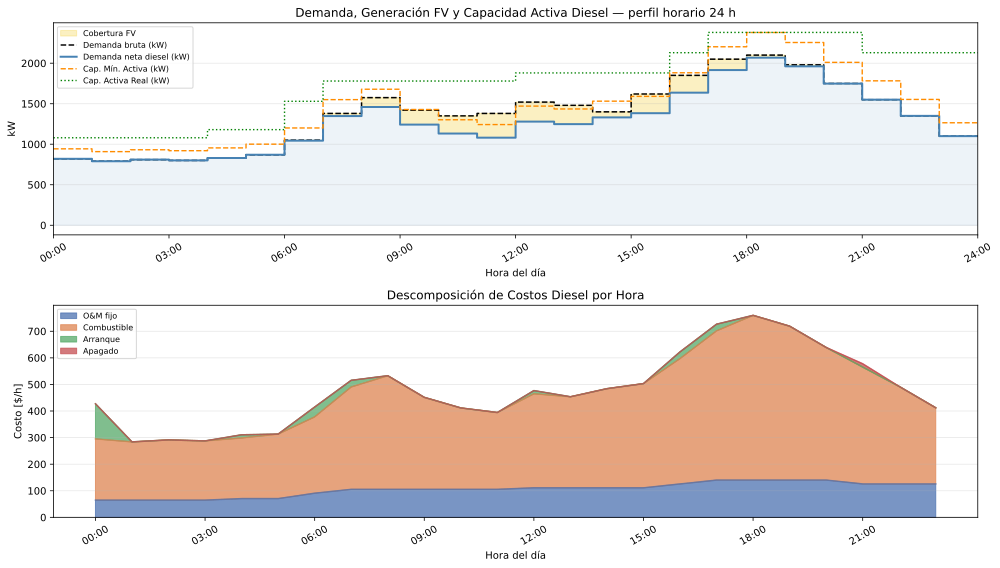

In [30]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']
sns.set_palette(sns.color_palette("deep"))

hours       = list(range(24))
demand_bruta_vals = list(time_period_data['expected_demand'])
pv_vals     = [pv_profile[i] for i in T]
demand_neta_vals  = [net_demand[i] for i in T]
min_cap_vals= [minimum_active_capacity[i] for i in T]
act_cap_vals= list(results_summary['Cap. Activa Real (kW)'])

def make_step(values):
    xs, ys = [], []
    for h, v in enumerate(values):
        xs += [h, h + 1]; ys += [v, v]
    return xs, ys

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ── Gráfico 1: Demanda bruta, neta, FV y capacidad activa ─────────────────────
ax1 = axes[0]
xs_db, ys_db = make_step(demand_bruta_vals)
xs_dn, ys_dn = make_step(demand_neta_vals)
xs_pv, ys_pv = make_step(pv_vals)
xs_mc, ys_mc = make_step(min_cap_vals)
xs_ac, ys_ac = make_step(act_cap_vals)

ax1.fill_between(xs_db, ys_db, ys_dn, alpha=0.25, color='#f1c40f', step=None, label='Cobertura FV')
ax1.fill_between(xs_dn, ys_dn, alpha=0.10, color='steelblue', step=None)
ax1.plot(xs_db, ys_db, 'k--',        lw=1.5,       label='Demanda bruta (kW)')
ax1.plot(xs_dn, ys_dn, 'steelblue',  lw=2,         label='Demanda neta diesel (kW)')
ax1.plot(xs_mc, ys_mc, 'darkorange', lw=1.4, ls='--', label='Cap. Mín. Activa (kW)')
ax1.plot(xs_ac, ys_ac, 'green',      lw=1.4, ls=':',  label='Cap. Activa Real (kW)')

ax1.set_xlabel("Hora del día"); ax1.set_ylabel("kW")
ax1.set_title("Demanda, Generación FV y Capacidad Activa Diesel — perfil horario 24 h")
ax1.set_xlim(0, 24); ax1.set_xticks(range(0, 25, 3))
ax1.set_xticklabels([f'{h:02d}:00' for h in range(0, 25, 3)], rotation=30)
ax1.legend(loc='upper left', fontsize=8); ax1.grid(alpha=0.3, axis='y')

# ── Gráfico 2: Descomposición de costos por hora ──────────────────────────────
ax2 = axes[1]
period_costs = pd.DataFrame(index=hours)
for component, label in [
    ('cost_fixed ($)', 'O&M fijo'), ('cost_fuel ($)', 'Combustible'),
    ('cost_startup ($)', 'Arranque'), ('cost_shutdown ($)', 'Apagado'),
]:
    period_costs[label] = solution.groupby('time_period')[component].sum().values

period_costs.plot.area(ax=ax2, alpha=0.75)
ax2.set_xlabel("Hora del día"); ax2.set_ylabel("Costo [$/h]")
ax2.set_title("Descomposición de Costos Diesel por Hora")
ax2.set_xticks(range(0, 24, 3))
ax2.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)], rotation=30)
ax2.legend(fontsize=8, loc='upper left'); ax2.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

In [31]:
active_matrix = pd.DataFrame(
    index=GENERATORS,
    columns=[str(t.time()) for t in TIME_PERIODS],
    data=[[int(round(pe.value(model.num_active[g, i]))) for i in T] for g in GENERATORS]
)

output_matrix = pd.DataFrame(
    index=GENERATORS,
    columns=[str(t.time()) for t in TIME_PERIODS],
    data=[[round(pe.value(model.output[g, i]), 1) for i in T] for g in GENERATORS]
)

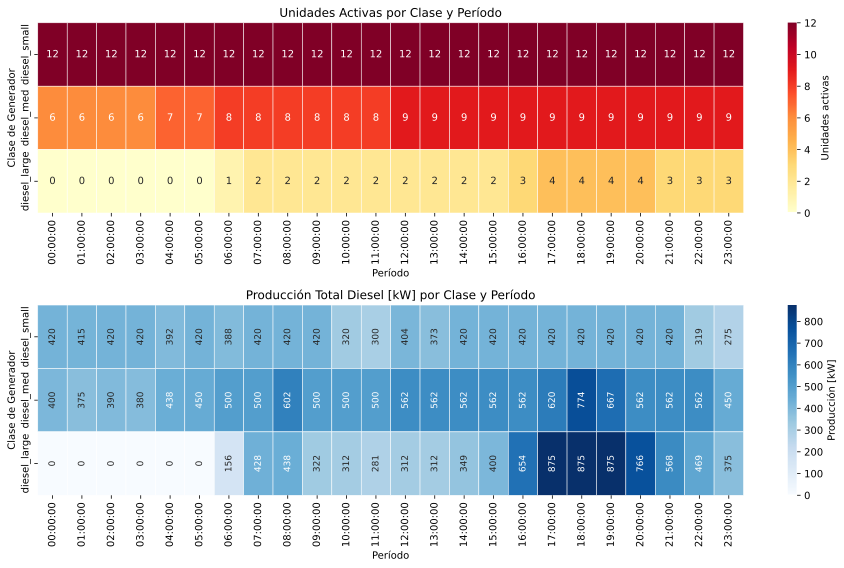

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

sns.heatmap(active_matrix, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Unidades activas'}, ax=axes[0])
axes[0].set_title("Unidades Activas por Clase y Período")
axes[0].set_xlabel("Período"); axes[0].set_ylabel("Clase de Generador")

sns.heatmap(output_matrix, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'Producción [kW]'},
            annot_kws={"size": 9, "rotation": 90}, ax=axes[1])
axes[1].set_title("Producción Total Diesel [kW] por Clase y Período")
axes[1].set_xlabel("Período"); axes[1].set_ylabel("Clase de Generador")

plt.tight_layout(); plt.show()

### Mix de Generación y Curva de Duración de Carga

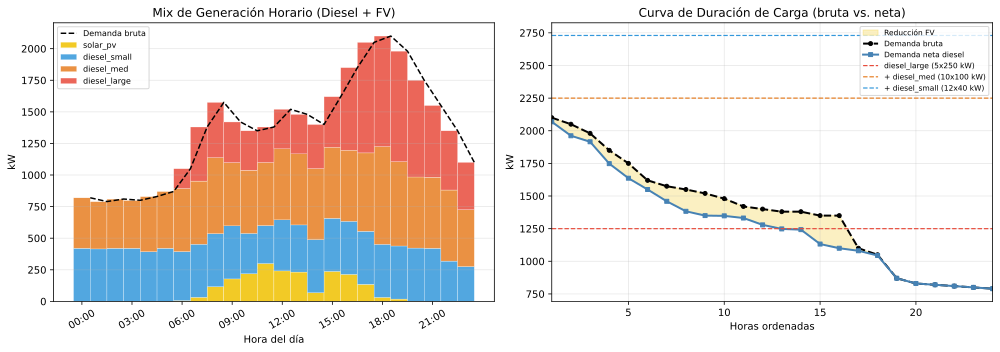

In [33]:
gen_colors = {'diesel_small': '#3498db', 'diesel_med': '#e67e22', 'diesel_large': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Mix de generación horario (área apilada) con FV ───────────────────────────
ax1 = axes[0]
bottoms = np.zeros(24)

# FV primero (base de la pila)
ax1.bar(hours, pv_vals, bottom=bottoms, color='#f1c40f',
        alpha=0.9, label='solar_pv', width=1.0, edgecolor='white', linewidth=0.3)
bottoms += np.array(pv_vals)

for g in GENERATORS:
    vals = [pe.value(model.output[g, i]) for i in T]
    ax1.bar(hours, vals, bottom=bottoms, color=gen_colors[g],
            alpha=0.85, label=g, width=1.0, edgecolor='white', linewidth=0.3)
    bottoms += np.array(vals)

ax1.plot([h + 0.5 for h in hours], demand_bruta_vals, 'k--', lw=1.5, label='Demanda bruta', zorder=5)
ax1.set_xlabel("Hora del día"); ax1.set_ylabel("kW")
ax1.set_title("Mix de Generación Horario (Diesel + FV)")
ax1.set_xticks(range(0, 24, 3)); ax1.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)], rotation=30)
ax1.legend(fontsize=8); ax1.grid(alpha=0.3, axis='y')

# ── Curva de duración de carga (con y sin FV) ─────────────────────────────────
ax2 = axes[1]
sorted_bruta = sorted(demand_bruta_vals, reverse=True)
sorted_neta  = sorted(demand_neta_vals,  reverse=True)
ax2.fill_between(range(1, 25), sorted_bruta, sorted_neta, alpha=0.25, color='#f1c40f', label='Reducción FV')
ax2.plot(range(1, 25), sorted_bruta, 'k--',       lw=2, marker='o', ms=4, label='Demanda bruta')
ax2.plot(range(1, 25), sorted_neta,  'steelblue', lw=2, marker='s', ms=4, label='Demanda neta diesel')

cap_lines = [
    (5*250,              'diesel_large (5x250 kW)', '#e74c3c'),
    (5*250+10*100,       '+ diesel_med (10x100 kW)', '#e67e22'),
    (5*250+10*100+12*40, '+ diesel_small (12x40 kW)', '#3498db'),
]
for cap, lbl, col in cap_lines:
    ax2.axhline(cap, color=col, lw=1.2, ls='--', label=lbl)

ax2.set_xlabel("Horas ordenadas"); ax2.set_ylabel("kW")
ax2.set_title("Curva de Duración de Carga (bruta vs. neta)")
ax2.set_xlim(1, 24); ax2.legend(fontsize=7.5, loc='upper right'); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

La Curva de Duración de Carga con generación FV muestra cómo la generación solar **desplaza hacia abajo** la curva de demanda neta durante las horas centrales del día. La zona amarilla representa la energía cubierta por el GFV en cada hora ordenada. Al reducirse la demanda neta, el despacho diesel es menor y potencialmente se pueden apagar unidades durante las horas de mayor irradiación solar.

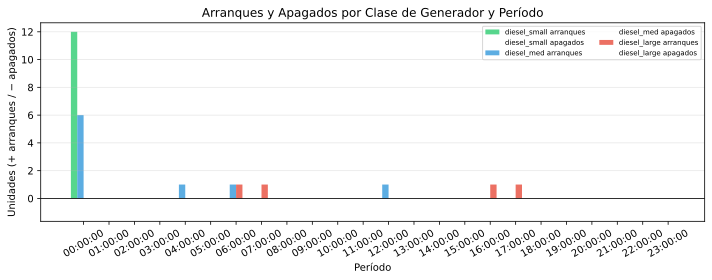

In [34]:
fig, ax = plt.subplots(figsize=(10, 4))
width = 0.25
x = np.arange(len(TIME_PERIODS))
labels = [str(t.time()) for t in TIME_PERIODS]
colors_start = ['#2ecc71', '#3498db', '#e74c3c']
colors_stop  = ['#27ae60', '#2980b9', '#c0392b']

for idx, g in enumerate(GENERATORS):
    starts = [int(round(pe.value(model.num_startup[g, i])))  for i in T]
    stops  = [int(round(pe.value(model.num_shutdown[g, i]))) for i in T]
    offset = (idx - 1) * width
    ax.bar(x+offset-width/2, starts,          width, color=colors_start[idx], alpha=0.8, label=f'{g} arranques')
    ax.bar(x+offset-width/2, [-s for s in stops], width, color=colors_stop[idx], alpha=0.4, hatch='//', label=f'{g} apagados')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30)
ax.set_xlabel("Período"); ax.set_ylabel("Unidades (+ arranques / − apagados)")
ax.set_title("Arranques y Apagados por Clase de Generador y Período")
ax.legend(fontsize=7, ncol=2, loc='upper right')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

### Análisis de Rampa: Verificación de Restricciones

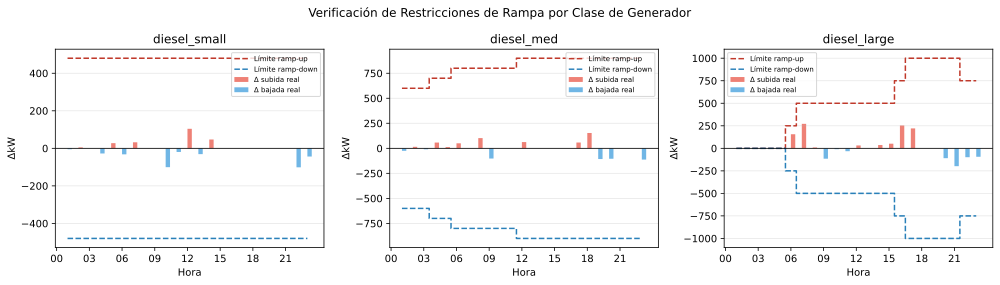


Violaciones de rampa (debe ser 0):
Clase            Ramp-up activo   Ramp-down activo
--------------------------------------------------
diesel_small                  0                  0
diesel_med                    0                  0
diesel_large                  0                  0


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Verificación de Restricciones de Rampa por Clase de Generador', fontsize=12)

for ax, g in zip(axes, GENERATORS):
    output_vals  = [pe.value(model.output[g, i])    for i in T]
    active_vals  = [int(round(pe.value(model.num_active[g, i])))  for i in T]
    startup_vals = [int(round(pe.value(model.num_startup[g, i]))) for i in T]
    shutdn_vals  = [int(round(pe.value(model.num_shutdown[g, i]))) for i in T]

    delta_up = []; delta_down = []; limit_up = []; limit_down = []
    for i in range(1, len(T)):
        diff = output_vals[i] - output_vals[i-1]
        delta_up.append(max(diff, 0)); delta_down.append(max(-diff, 0))
        limit_up.append(ramp_limit[g]*active_vals[i-1] + max_output[g]*startup_vals[i])
        limit_down.append(ramp_limit[g]*active_vals[i] + max_output[g]*shutdn_vals[i])

    hours_mid = list(range(1, 24))
    ax.bar(hours_mid, delta_up,             color='#e74c3c', alpha=0.7, width=0.4, label='Δ subida real',  align='edge')
    ax.bar(hours_mid, [-d for d in delta_down], color='#3498db', alpha=0.7, width=0.4, label='Δ bajada real', align='edge')
    ax.step(hours_mid, limit_up,              color='#c0392b', lw=1.5, ls='--', where='mid', label='Límite ramp-up')
    ax.step(hours_mid, [-l for l in limit_down], color='#2980b9', lw=1.5, ls='--', where='mid', label='Límite ramp-down')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(g); ax.set_xlabel('Hora'); ax.set_ylabel('ΔkW')
    ax.set_xticks(range(0,24,3)); ax.set_xticklabels([f'{h:02d}' for h in range(0,24,3)])
    ax.legend(fontsize=7); ax.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

print('\nViolaciones de rampa (debe ser 0):')
print(f'{"Clase":<14} {"Ramp-up activo":>16} {"Ramp-down activo":>18}')
print('-'*50)
for g in GENERATORS:
    output_vals  = [pe.value(model.output[g, i]) for i in T]
    active_vals  = [int(round(pe.value(model.num_active[g, i])))  for i in T]
    startup_vals = [int(round(pe.value(model.num_startup[g, i]))) for i in T]
    shutdn_vals  = [int(round(pe.value(model.num_shutdown[g, i]))) for i in T]
    n_up = n_dn = 0
    for i in range(1, len(T)):
        lim_up = ramp_limit[g]*active_vals[i-1] + max_output[g]*startup_vals[i]
        lim_dn = ramp_limit[g]*active_vals[i]   + max_output[g]*shutdn_vals[i]
        diff = output_vals[i] - output_vals[i-1]
        if diff  > lim_up + 1e-4: n_up += 1
        if -diff > lim_dn + 1e-4: n_dn += 1
    print(f'{g:<14} {n_up:>16} {n_dn:>18}')

Se observa que las barras llenas nunca superan las líneas discontinuas, verificando la factibilidad de las soluciones. Con `ramp_limit = max_output` las restricciones son trivialmente satisfechas y nunca activas.

In [36]:
print("\nEstadísticas globales:")
print(f"   Costo total óptimo    : ${costo_total:,.2f}")
print(f"   Clases generadores    : {len(GENERATORS)}")
print(f"   Períodos              : {len(T)}")
print(f"   Total unidades diesel : {sum(num_available.values())}")
print(f"   Segmentos lin.        : {N_SEG}")

total_starts = sum(int(round(pe.value(model.num_startup[g, i])))  for g in GENERATORS for i in T)
total_stops  = sum(int(round(pe.value(model.num_shutdown[g, i]))) for g in GENERATORS for i in T)
print(f"   Total arranques       : {total_starts}")
print(f"   Total apagados        : {total_stops}")
print(f"   Costo medio por kWh   : ${costo_total / sum(net_demand.values()):.4f}/kWh (sobre energía neta diesel)")
print()
print(f"── Contribución fotovoltaica ──────────────────────────────")
total_pv_energy  = sum(pv_profile.values())
total_dem_energy = sum(expected_demand.values())
print(f"   Energía FV            : {total_pv_energy:.1f} kWh/día")
print(f"   Energía diesel        : {sum(net_demand.values()):.1f} kWh/día")
print(f"   Energía total         : {total_dem_energy:.0f} kWh/día")
print(f"   Penetración FV        : {100*total_pv_energy/total_dem_energy:.1f}%")


Estadísticas globales:
   Costo total óptimo    : $11,499.73
   Clases generadores    : 3
   Períodos              : 24
   Total unidades diesel : 27
   Segmentos lin.        : 3
   Total arranques       : 25
   Total apagados        : 1
   Costo medio por kWh   : $0.3734/kWh (sobre energía neta diesel)

── Contribución fotovoltaica ──────────────────────────────
   Energía FV            : 2026.5 kWh/día
   Energía diesel        : 30798.5 kWh/día
   Energía total         : 32825 kWh/día
   Penetración FV        : 6.2%


### Análisis Económico: Costos Unitarios y Comparación de Componentes

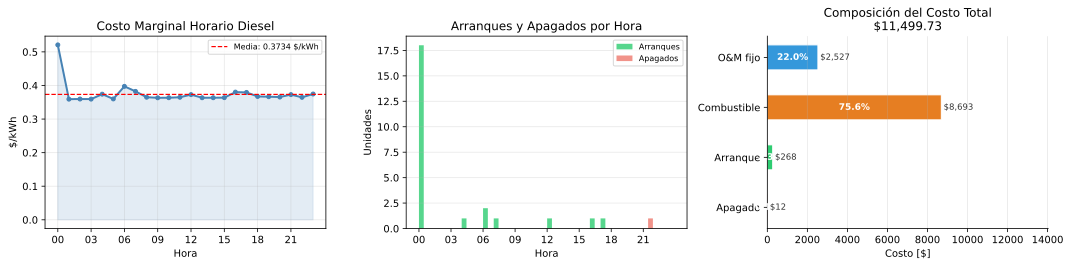


Resumen económico por clase de generador:
Clase           Energía (kWh)  Horas activo  C. Total ($)    $/kWh  Factor uso
----------------------------------------------------------------------------
diesel_small             9486           288       3418.75   0.3604       0.823
diesel_med              12545           194       4697.70   0.3745       0.523
diesel_large             8767            47       3383.30   0.3859       0.292
----------------------------------------------------------------------------
Diesel total            30798                    11499.73   0.3734
FV                     2026.5             —          0.00   0.0000              (sin costo variable)
TOTAL                   32825                    11499.73   0.3503  (sobre demanda bruta)


In [37]:
# ── Costo marginal horario ($/kWh) ────────────────────────────────────────────
hourly_cost = period_costs.sum(axis=1).values
hourly_cost_per_kwh = hourly_cost / np.array(demand_neta_vals)   # costo diesel por kWh neto

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

ax1 = axes[0]
ax1.plot(hours, hourly_cost_per_kwh, 'steelblue', lw=2, marker='o', ms=4)
ax1.fill_between(hours, hourly_cost_per_kwh, alpha=0.15, color='steelblue')
media_kwh = costo_total / sum(net_demand.values())
ax1.axhline(media_kwh, color='red', lw=1.2, ls='--',
            label=f'Media: {media_kwh:.4f} $/kWh')
ax1.set_xlabel("Hora"); ax1.set_ylabel("$/kWh")
ax1.set_title("Costo Marginal Horario Diesel")
ax1.set_xticks(range(0,24,3)); ax1.set_xticklabels([f'{h:02d}' for h in range(0,24,3)])
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# 2. Arranques y apagados acumulados por hora
ax2 = axes[1]
starts_total = [sum(int(round(pe.value(model.num_startup[g,i])))  for g in GENERATORS) for i in T]
stops_total  = [sum(int(round(pe.value(model.num_shutdown[g,i]))) for g in GENERATORS) for i in T]
ax2.bar(hours, starts_total,               color='#2ecc71', alpha=0.8, label='Arranques', width=0.45, align='edge')
ax2.bar([h+0.45 for h in hours], stops_total, color='#e74c3c', alpha=0.6, label='Apagados', width=0.45, align='edge')
ax2.set_xlabel("Hora"); ax2.set_ylabel("Unidades")
ax2.set_title("Arranques y Apagados por Hora")
ax2.set_xticks(range(0,24,3)); ax2.set_xticklabels([f'{h:02d}' for h in range(0,24,3)])
ax2.legend(fontsize=8); ax2.grid(alpha=0.3, axis='y')

# 3. Comparación de componentes de costo (barras apiladas)
ax3 = axes[2]
cost_components = {'O&M fijo': period_costs['O&M fijo'].sum(),
                   'Combustible': period_costs['Combustible'].sum(),
                   'Arranque': period_costs['Arranque'].sum(),
                   'Apagado':  period_costs['Apagado'].sum()}
wedge_colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c']
labels_c = list(cost_components.keys())
values_c = list(cost_components.values())
total_c  = sum(values_c)
bars = ax3.barh(labels_c, values_c, color=wedge_colors, edgecolor='white', height=0.5)
for bar, pct, val in zip(bars, [v/total_c*100 for v in values_c], values_c):
    ax3.text(bar.get_width()/2, bar.get_y()+bar.get_height()/2,
             f'{pct:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    ax3.text(bar.get_width()+total_c*0.01, bar.get_y()+bar.get_height()/2,
             f'${val:,.0f}', ha='left', va='center', fontsize=8.5, color='#333333')
ax3.set_xlabel("Costo [$]")
ax3.set_title(f"Composición del Costo Total\n${costo_total:,.2f}")
ax3.set_xlim(0, total_c*1.22); ax3.invert_yaxis()
ax3.grid(alpha=0.3, axis='x'); ax3.spines[['top','right']].set_visible(False)

plt.tight_layout(); plt.show()

# ── Tabla resumen por clase de generador ─────────────────────────────────────
print("\nResumen económico por clase de generador:")
print(f"{'Clase':<14} {'Energía (kWh)':>14} {'Horas activo':>13} {'C. Total ($)':>13} {'$/kWh':>8} {'Factor uso':>11}")
print("-" * 76)
for g in GENERATORS:
    energia  = sum(pe.value(model.output[g, i]) for i in T)
    h_activo = sum(int(round(pe.value(model.num_active[g, i]))) for i in T)
    c_tot    = solution.loc[g, 'cost_total ($)'].sum()
    max_cap  = generator_data.loc[g,'max_output'] * generator_data.loc[g,'num_available']
    f_uso    = energia / (max_cap * 24)
    print(f"{g:<14} {energia:>14.0f} {h_activo:>13d} {c_tot:>13.2f} {c_tot/energia if energia>0 else 0:>8.4f} {f_uso:>11.3f}")
print("-" * 76)
print(f"{'Diesel total':<14} {sum(net_demand.values()):>14.0f} {'':>13} {costo_total:>13.2f} {costo_total/sum(net_demand.values()):>8.4f}")
print(f"{'FV':<14} {sum(pv_profile.values()):>14.1f} {'—':>13} {'0.00':>13} {'0.0000':>8} {'':>11}  (sin costo variable)")
print(f"{'TOTAL':<14} {sum(expected_demand.values()):>14.0f} {'':>13} {costo_total:>13.2f} {costo_total/sum(expected_demand.values()):>8.4f}  (sobre demanda bruta)")

## Conclusiones

Este modelo implementa un Unit Commitment + Despacho Económico para una microrred diesel con generación fotovoltaica integrada, con las siguientes extensiones sobre el ejemplo original de Williams:

1. Redimensionamiento a escala de microrred: demanda escalada de ~45 GW a ~2,1 MW pico, con tres clases de generadores diesel de 40, 100 y 250 kW.

2. Costos de apagado: `num_shutdown` y `shutdown_cost` capturan los costos de detención (50% del costo de arranque, Nemati et al.).

3. Tiempos mínimos de encendido/apagado: restricciones MUT y MDT para evitar ciclado excesivo (Parisio, 2014).

4. Linealización Parisio de la curva de combustible: variable auxiliar $\sigma_{g,t}$ y restricciones de segmentos tangentes mantienen la naturaleza MILP del problema.

5. Restricciones de rampa (V4): formuladas con $R_g = P^{\max}_g$ (trivialmente satisfechas). Los generadores diesel tienen dinámica mucho más rápida que el paso de tiempo de 1 hora.

6. Generación fotovoltaica — modelo Loyarte (V5): el GFV de 400 kWp se modela en pre-proceso mediante las ecuaciones de Loyarte (ecs. 1-2). La potencia horaria $P^{\mathrm{PV}}_t$ es un parámetro determinístico calculado a partir de datos reales de irradiancia y temperatura del parque UTN FR Santa Fe (01/01/2019). La demanda que deben cubrir los generadores diesel se reduce a la demanda neta:
   $$D^{\mathrm{net}}_t = D_t - P^{\mathrm{PV}}_t$$
   La generación solar pico alcanza ~300 kW (hora 11), cubriendo el 6% de la energía diaria total. La reserva operativa se recalcula sobre la demanda neta, reduciendo también la capacidad mínima requerida durante las horas solares. Esta integración reduce tanto el costo total de operación como el despacho de generadores diesel durante las horas centrales del día.